# Fake Review Detection using Machine Learning

## Objective
Build a machine learning model to detect fake product reviews.

## Dataset
- Total Reviews: 40,432
- Features:
  - Category
  - Rating
  - Review Text
  - Label (Fake/Genuine)

## Workflow
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Flask Deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../dataset/fake_reviews.csv")

In [3]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  str    
 1   rating    40432 non-null  float64
 2   label     40432 non-null  str    
 3   text_     40432 non-null  str    
dtypes: float64(1), str(3)
memory usage: 1.2 MB


In [5]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [6]:
df.shape

(40432, 4)

In [7]:
df.columns

Index(['category', 'rating', 'label', 'text_'], dtype='str')

In [8]:
df.describe()

,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [9]:
df["label"].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

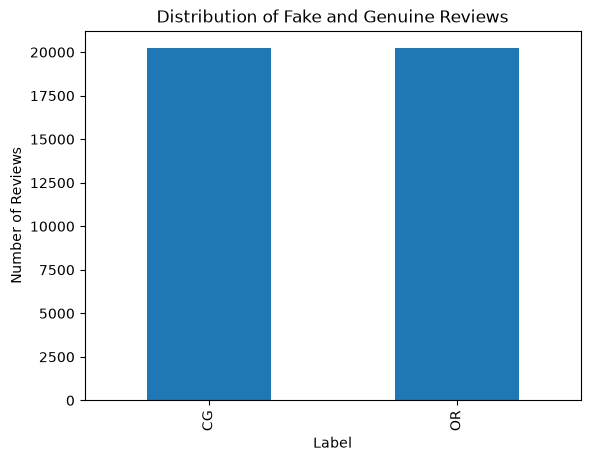

In [10]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Fake and Genuine Reviews")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")

plt.show()

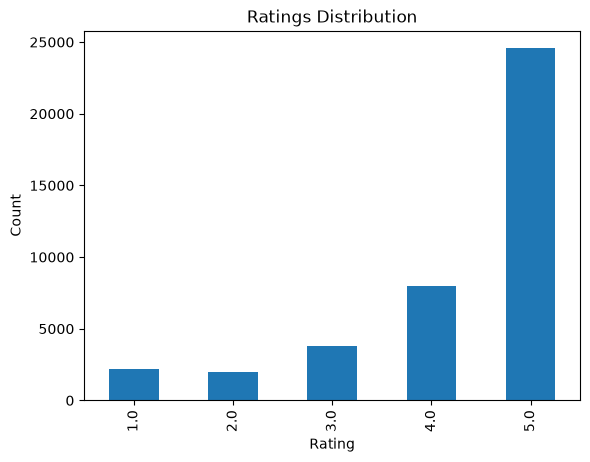

In [11]:
df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [12]:
df["category"].value_counts().head(10)

category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: count, dtype: int64

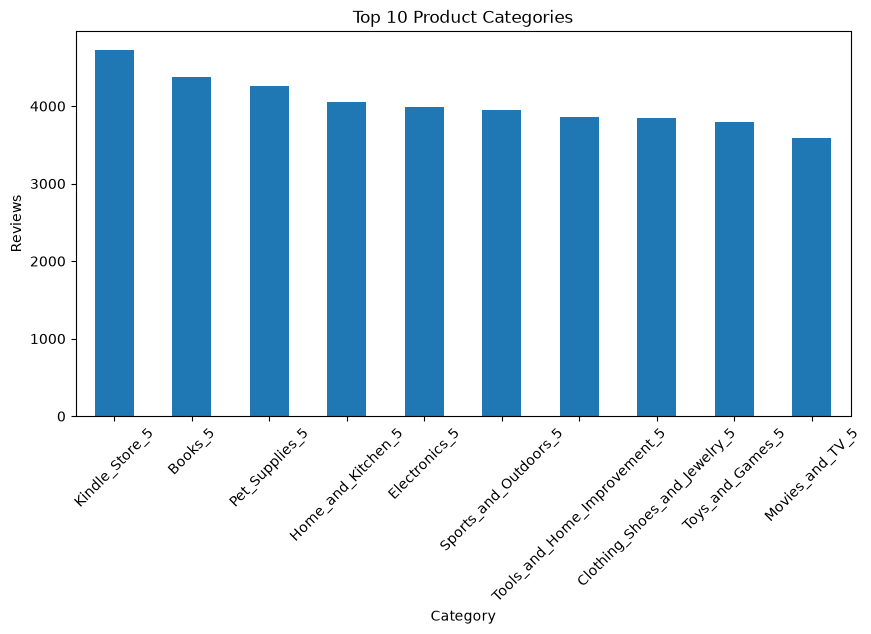

In [13]:
df["category"].value_counts().head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Reviews")

plt.xticks(rotation=45)

plt.show()

# Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:

- Distribution of Fake vs Genuine Reviews
- Rating Distribution
- Product Category Distribution
- Review Length
- Patterns in the data

These insights help us understand the dataset before training the machine learning model.

In [14]:
df["label"].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

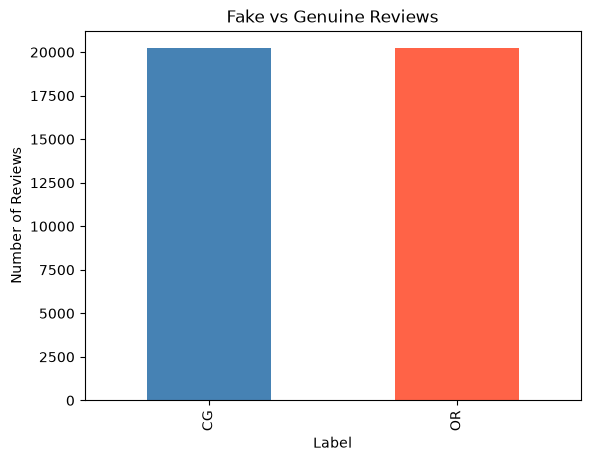

In [15]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Fake vs Genuine Reviews")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")

plt.show()

In [16]:
df["rating"].value_counts().sort_index()

rating
1.0     2155
2.0     1967
3.0     3786
4.0     7965
5.0    24559
Name: count, dtype: int64

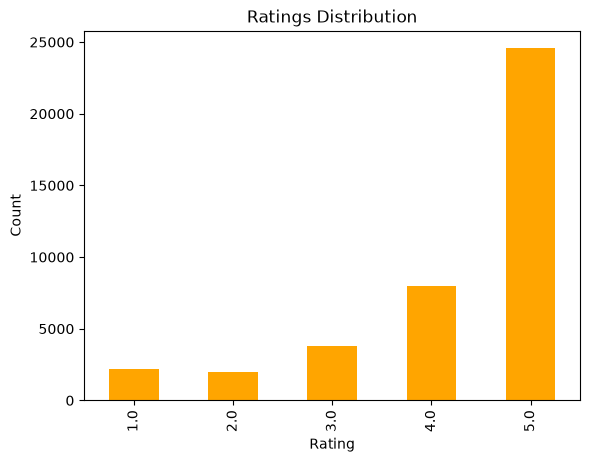

In [17]:
df["rating"].value_counts().sort_index().plot(
    kind="bar",
    color="orange"
)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [18]:
df["category"].value_counts().head(10)

category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: count, dtype: int64

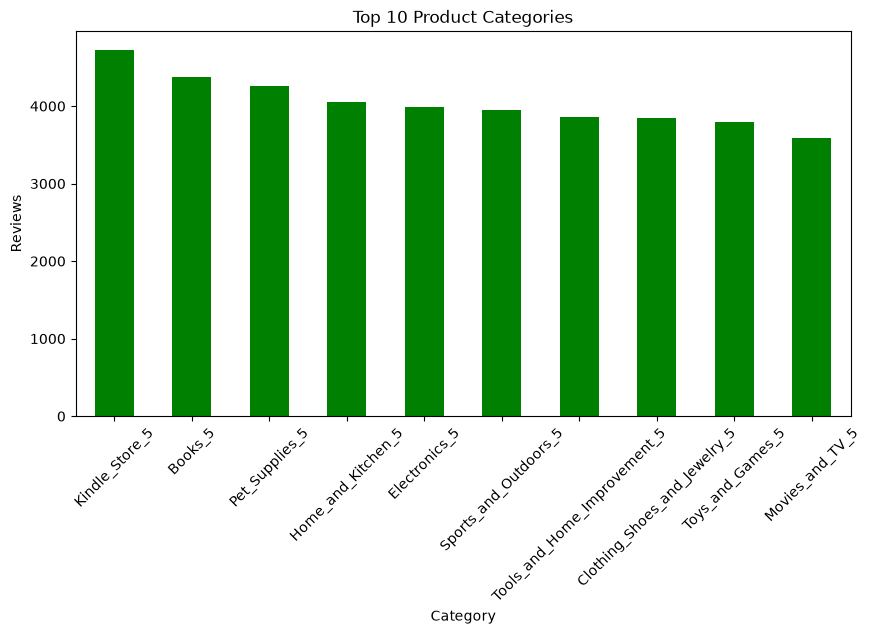

In [19]:
df["category"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    color="green"
)

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Reviews")

plt.xticks(rotation=45)

plt.show()

## Review Length Analysis

In [20]:
df["review_length"] = df["text_"].apply(len)

df["review_length"].describe()

count    40432.000000
mean       351.271963
std        369.813570
min         24.000000
25%        107.000000
50%        198.000000
75%        439.000000
max       2827.000000
Name: review_length, dtype: float64

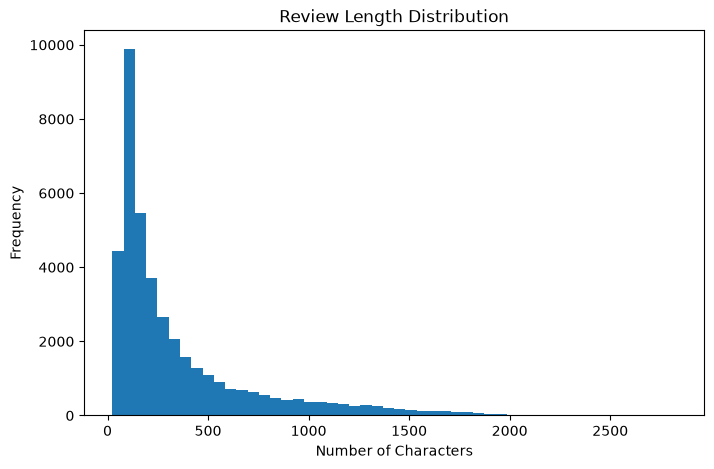

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most reviews are relatively short.
- A few reviews are much longer than average.
- Review length may help distinguish fake and genuine reviews.

# Text Preprocessing

In [22]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [24]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

In [25]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/harshavardhini/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/harshavardhini/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/harshavardhini/nltk_data...


True

In [26]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [27]:
 def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [28]:
df["clean_review"] = df["text_"].apply(clean_text)

# Feature Engineering using TF-IDF

## Objective

Machine learning algorithms cannot understand raw text directly. Therefore, the cleaned review text is converted into numerical feature vectors using the Term Frequency–Inverse Document Frequency (TF-IDF) technique.

TF-IDF assigns higher importance to words that are frequent in a review but uncommon across the entire dataset, making them more useful for classification.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
tfidf = TfidfVectorizer(max_features=5000)

In [36]:
X = tfidf.fit_transform(df["clean_review"])

In [37]:
y = df["label"]

In [38]:
print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (40432, 5000)
Labels Shape: (40432,)


## Observation

The review text has been successfully converted into numerical feature vectors using TF-IDF.

The dataset now contains 40,432 review samples represented by the 5,000 most informative textual features. These numerical features will be used to train and evaluate machine learning models.

# Train-Test Split

## Objective

The dataset is divided into training and testing sets.

- **Training Set (80%)**: Used to train the machine learning model.
- **Testing Set (20%)**: Used to evaluate the model on unseen data.

This helps assess how well the model generalizes to new reviews.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (32345, 5000)
Testing Features: (8087, 5000)
Training Labels: (32345,)
Testing Labels: (8087,)


# 🤖 Machine Learning Model Training

In this section, we train different machine learning algorithms on the processed review dataset.

The models used are:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

After training, we will compare their performance and choose the best model for fake review detection.

# 🤖 Multinomial Naive Bayes

We first train a Multinomial Naive Bayes classifier. This algorithm is widely used for text classification because it is fast and performs well on TF-IDF features.

In [40]:
from sklearn.naive_bayes import MultinomialNB

# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


# 🔍 Predictions using Naive Bayes

After training the model, we predict the labels for the testing dataset.

In [41]:
y_pred_nb = nb_model.predict(X_test)

print(y_pred_nb[:10])

['CG' 'CG' 'OR' 'CG' 'OR' 'OR' 'CG' 'OR' 'CG' 'OR']


# 📊 Naive Bayes Evaluation

We evaluate the model using:

- Accuracy Score
- Classification Report
- Confusion Matrix

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb)

Accuracy: 0.8497588722641276


In [43]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

          CG       0.84      0.87      0.85      4016
          OR       0.87      0.83      0.85      4071

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087



In [44]:
print(confusion_matrix(y_test, y_pred_nb))

[[3489  527]
 [ 688 3383]]


# 🤖 Logistic Regression

Logistic Regression is one of the most effective machine learning algorithms for text classification. It often performs better than Naive Bayes when used with TF-IDF features.

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 🔍 Predictions using Logistic Regression

We now use the trained Logistic Regression model to predict whether reviews are genuine or fake.

In [47]:
y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:10])

['CG' 'CG' 'OR' 'CG' 'OR' 'OR' 'CG' 'OR' 'CG' 'OR']


# 📊 Logistic Regression Evaluation

The model is evaluated using:

- Accuracy
- Classification Report
- Confusion Matrix

In [48]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8720168171138865


In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

          CG       0.88      0.86      0.87      4016
          OR       0.86      0.89      0.87      4071

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



In [50]:
print(confusion_matrix(y_test, y_pred_lr))

[[3445  571]
 [ 464 3607]]


# 🤖 Linear Support Vector Machine (SVM)

Linear SVM is a powerful supervised machine learning algorithm for text classification. It works well with high-dimensional TF-IDF features and often provides the highest accuracy among traditional machine learning models.

In [51]:
from sklearn.svm import LinearSVC

In [52]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


# 🔍 Predictions using Linear SVM

The trained Linear SVM model is used to classify reviews as genuine or fake.

In [53]:
y_pred_svm = svm_model.predict(X_test)

print(y_pred_svm[:10])

['CG' 'CG' 'OR' 'CG' 'OR' 'OR' 'CG' 'OR' 'CG' 'OR']


# 📊 Linear SVM Evaluation

We evaluate the model using:

- Accuracy Score
- Classification Report
- Confusion Matrix

In [54]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", accuracy_svm)

Linear SVM Accuracy: 0.8778286138246568


In [55]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

          CG       0.88      0.88      0.88      4016
          OR       0.88      0.88      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



In [56]:
print(confusion_matrix(y_test, y_pred_svm))

[[3526  490]
 [ 498 3573]]


# 📊 Model Comparison

Three machine learning models were trained and evaluated:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

We compare their accuracy scores to determine which model performs best for fake review detection.

In [57]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svm
    ]
})

comparison

,Model,Accuracy
0,Naive Bayes,0.849759
1,Logistic Regression,0.872017
2,Linear SVM,0.877829


In [58]:
comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
2,Linear SVM,0.877829
1,Logistic Regression,0.872017
0,Naive Bayes,0.849759


# 💾 Saving the Best Model

After comparing all machine learning models, the best-performing model is selected.

In this project, the **Linear SVM** achieved the highest accuracy. Therefore, both the trained model and the TF-IDF vectorizer are saved as `.pkl` files.

These saved files will be loaded later in the Flask web application to classify new reviews as **Fake** or **Genuine**.

In [63]:
import joblib

In [64]:
joblib.dump(svm_model, "../trained_model/review_model.pkl")

['../trained_model/review_model.pkl']

In [65]:
joblib.dump(tfidf, "../trained_model/tfidf_vectorizer.pkl")

['../trained_model/tfidf_vectorizer.pkl']

In [66]:
import os

print(os.listdir("../trained_model"))

['tfidf_vectorizer.pkl', 'review_model.pkl']


In [67]:
import joblib

model = joblib.load("../trained_model/review_model.pkl")
vectorizer = joblib.load("../trained_model/tfidf_vectorizer.pkl")

review = "This product is amazing. I loved it."

review_vector = vectorizer.transform([review])

print(model.predict(review_vector))

['CG']


In [68]:
review = "Worst purchase ever. Completely fake and useless."

review_vector = vectorizer.transform([review])

print(model.predict(review_vector))

['OR']
